# Исследование рынка недвижимости

## Изучение общей информации 

Импортируем библиотеки. Считаем данные из csv-файла в датафрейм и сохраним в переменную data.

In [1]:
# импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# чтение csv-файли и сохранение его в переменную data
try:
    data = pd.read_csv('C:/Users/evgen/Documents/data/Проекты по аналитике Яндекс/Данные для проектов/Исследование недвижимости/real_estate_data.csv', sep='\t')
except:
    data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')

Выводим на экран первые 10 строк csv-файла

In [3]:
# вывод на экран первых 10 строк файла
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


Изучим сводную информацию о таблице 

In [4]:
# просмотр сводной информации о таблице
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

Из сводной информации видно, что в данных имеются пропуски, которые нужно изучить подробнее, заполнить их или удалить. Так же тип данных в некоторых столбцах требуется привести к нужному виду (`first_day_exposition`, `floors_total`, `is_apartment`, `balcony`).

In [5]:
# сохраним изначальное количество строк и столбцов в переменной shape
shape = data.shape
# выведем значение переменной на экран
print(shape)

(23699, 22)


Проверим наличие в таблице явных дубликатов

In [6]:
data.duplicated().sum()

0

Построим общую гистограмму для всех числовых столбцов таблицы.

array([[<AxesSubplot:title={'center':'total_images'}>,
        <AxesSubplot:title={'center':'last_price'}>,
        <AxesSubplot:title={'center':'total_area'}>,
        <AxesSubplot:title={'center':'rooms'}>],
       [<AxesSubplot:title={'center':'ceiling_height'}>,
        <AxesSubplot:title={'center':'floors_total'}>,
        <AxesSubplot:title={'center':'living_area'}>,
        <AxesSubplot:title={'center':'floor'}>],
       [<AxesSubplot:title={'center':'kitchen_area'}>,
        <AxesSubplot:title={'center':'balcony'}>,
        <AxesSubplot:title={'center':'airports_nearest'}>,
        <AxesSubplot:title={'center':'cityCenters_nearest'}>],
       [<AxesSubplot:title={'center':'parks_around3000'}>,
        <AxesSubplot:title={'center':'parks_nearest'}>,
        <AxesSubplot:title={'center':'ponds_around3000'}>,
        <AxesSubplot:title={'center':'ponds_nearest'}>],
       [<AxesSubplot:title={'center':'days_exposition'}>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>]], d

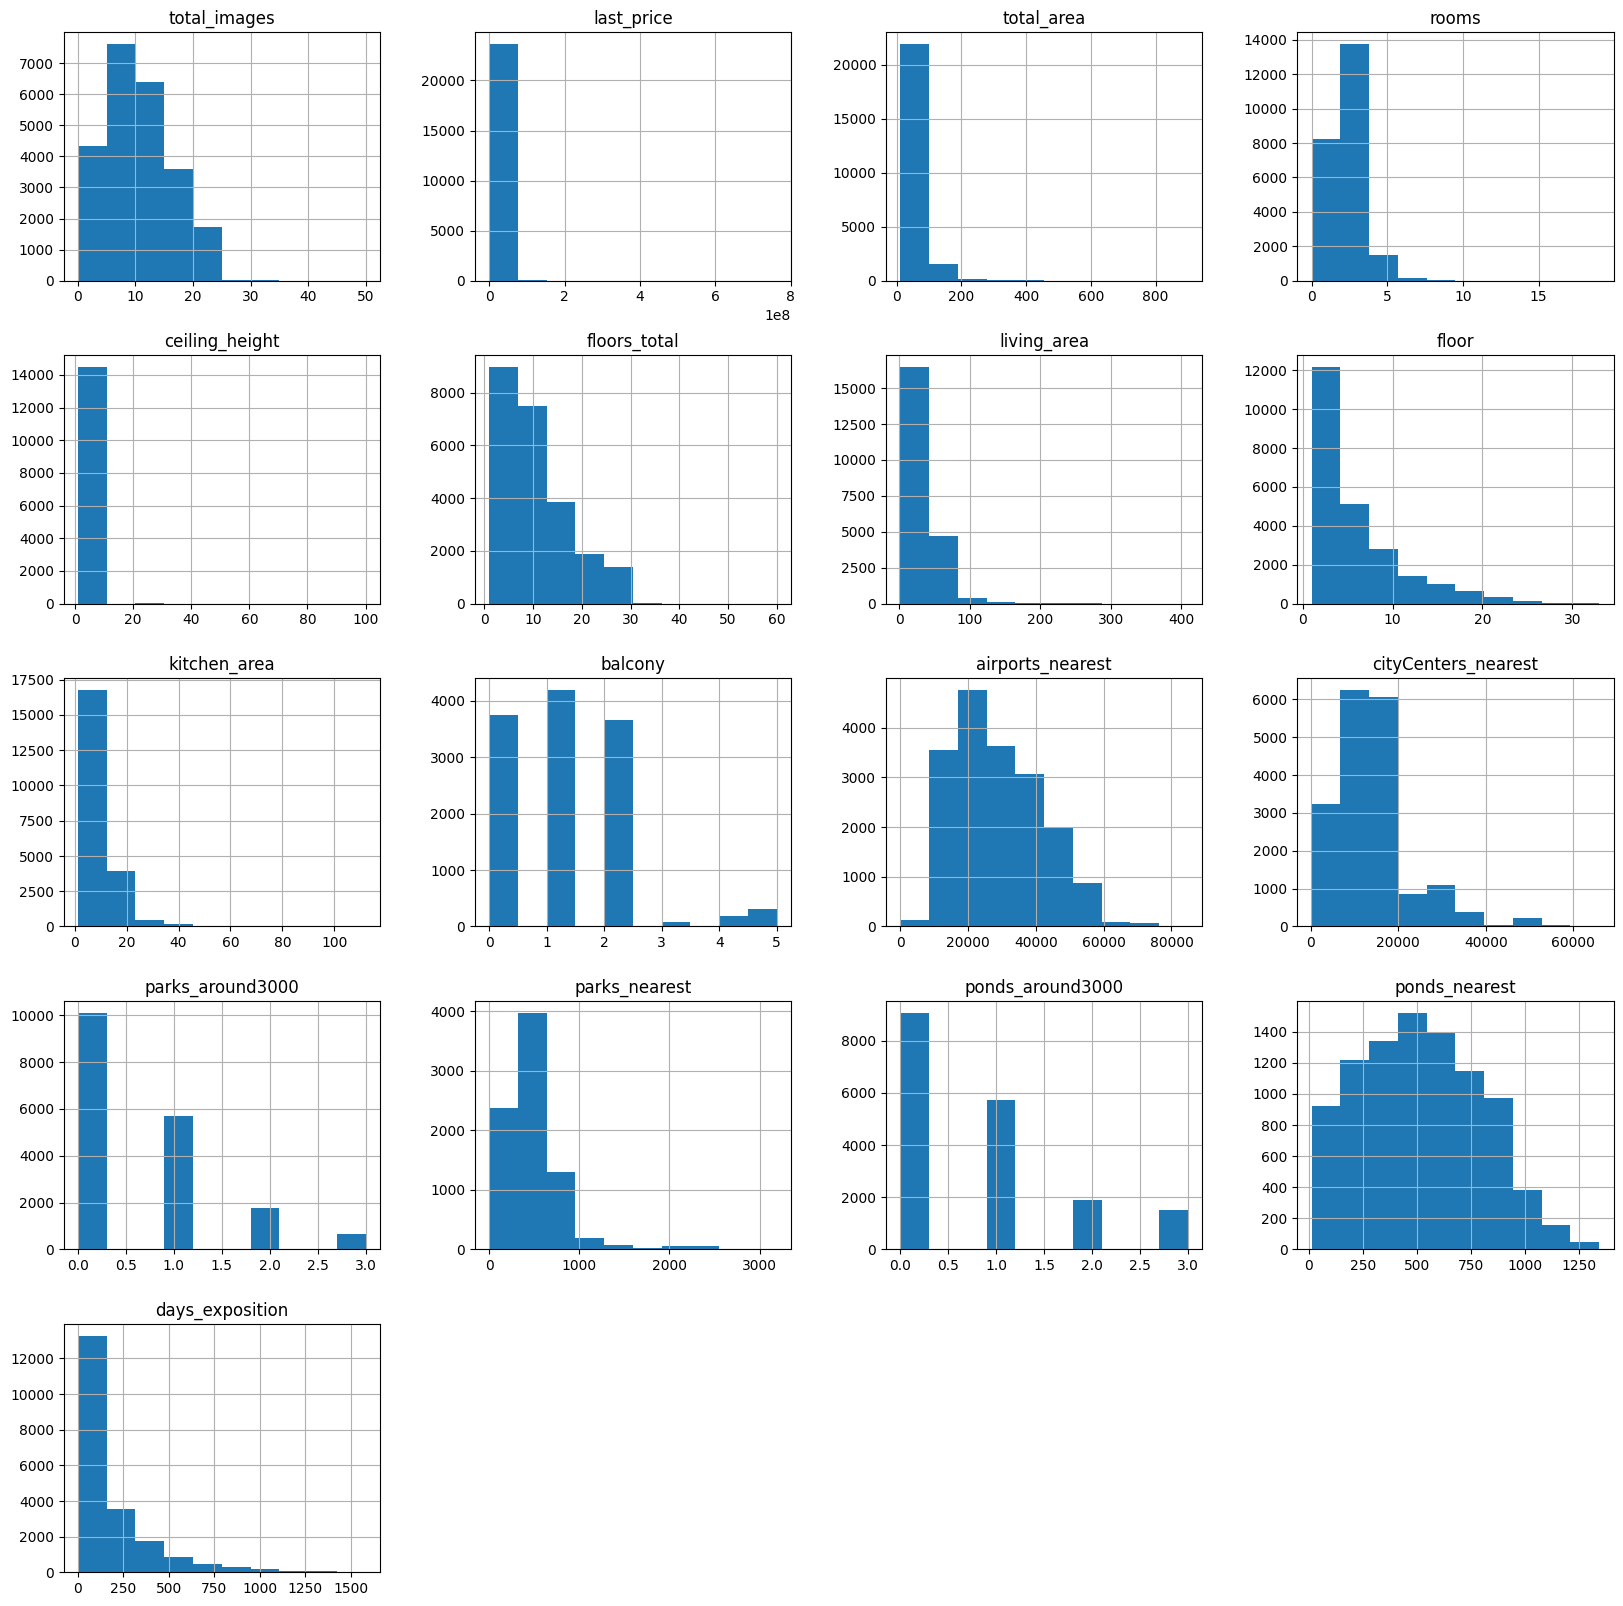

In [7]:
data.hist(figsize=(20, 20))

### Вывод по общей информации

Из сводной информации по таблице видно, что в таблице 23699 записи. В данных имеются пропуски, тип данных в некоторых столбцах требуется привести к нужному виду. Явные дубликаты в таблице не обнаружены. По гистограммам видно, что в данных есть аномальные значения.

## Предобработка данных

### Изучение пропущенных значений, изменение типов данных.

Изменим типы данных в столбцах last_price и first_day_exposition

In [8]:
# изменим тип данных в столбце last_price на int
data['last_price'] = data['last_price'].astype('int', errors='raise')

In [9]:
# изменим тип данных в столбце first_day_exposition на datetime
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')

Наименование столбца cityCenters_nearest изменим в соответствии с «змеиным регистром»

In [10]:
data = data.rename(columns={'cityCenters_nearest': 'city_centers_nearest'})

Подсчитаем количество пропущенных значений в каждом столбце

In [11]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
city_centers_nearest     5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

Изучим данные с столбце Высота потолков, чтобы решить какими значениями лучше заполнить пропуски.

In [12]:
# запросим список характерных значений
data['ceiling_height'].describe()

count    14504.000000
mean         2.771499
std          1.261056
min          1.000000
25%          2.520000
50%          2.650000
75%          2.800000
max        100.000000
Name: ceiling_height, dtype: float64

В первую очередь обращают на себя внимание не правдоподобные минимальные и максимальные значения - 1 и 100 метров, это очевидно выбросы. Не смотря на наличие выбросов, медиана(2,65) не сильно отличается от средней высоты потолков(2,77). Заполним пропуски медианными значениями.

In [13]:
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median())

Изучим выбросы - слишком высокие потолки

In [14]:
data['ceiling_height'].sort_values(ascending=False).head(30)

22869    100.0
3148      32.0
22336     32.0
21377     27.5
4876      27.0
17857     27.0
5246      27.0
20478     27.0
22938     27.0
5807      27.0
21824     27.0
10773     27.0
5669      26.0
18545     25.0
4643      25.0
9379      25.0
11285     25.0
14382     25.0
355       25.0
6246      25.0
5076      24.0
20507     22.6
17496     20.0
15061     14.0
22309     10.3
5863       8.3
3474       8.0
15743      8.0
17442      8.0
20264      6.0
Name: ceiling_height, dtype: float64

Слишком высокие значения высоты потолка видимо были получены из-за опечаток при вводе данных. Более реально данные будут выглядеть после переноса запятой влево.

In [15]:
# значения больше 20 разделим на 10 
data.loc[data['ceiling_height'] >= 20.0, 'ceiling_height'] = data['ceiling_height']/10

Проверим как изменились характерные значения.


In [16]:
data['ceiling_height'].describe()

count    23699.000000
mean         2.698721
std          0.253208
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max         14.000000
Name: ceiling_height, dtype: float64

Медиана и среднее почти равны, максимальное стало более приближено к реальным значениям

Изучим пропуски с столбце Аппартаменты.

In [17]:
data['is_apartment'].isna().sum()

20924

Так как аппартаменты встречаются не так часто, скорее всего пропуски обозначают что это не аппартаменты. Значит можно пропуски заполнить False

In [18]:
data['is_apartment'] = data['is_apartment'].fillna(False)

Посмотрим данные в столбцах Жилая площадь и Площадь кухни

In [19]:
# характерные значения в столбце жилая площадь
data['living_area'].describe()

count    21796.000000
mean        34.457852
std         22.030445
min          2.000000
25%         18.600000
50%         30.000000
75%         42.300000
max        409.700000
Name: living_area, dtype: float64

In [20]:
# характерные значения в столбце площадь кухни
data['kitchen_area'].describe()

count    21421.000000
mean        10.569807
std          5.905438
min          1.300000
25%          7.000000
50%          9.100000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

Доля пропусков в столбце Жилая площадь - 8%, в столбце Площадь кухни - 10%. Возможно данные пропуски возникли из-за типа помещения, например отсутствие кухни в квартире-студии. Поэтому не можем заполнить данные пропуски медианным или средним значением. Оставляем пока эти столбцы без изменений.

В столбце Всего этажей в доме 86 пропусков, которые возникли скорее всего из-за человеческого фактора - пользователи не вносили данный параметр. Можно удалить строки с пропуском в этом столбце, т.к. их очень мало.

In [21]:
# удалим строки с пропусками в столбце Всего этажей
data = data.dropna(subset=['floors_total'])

In [22]:
# проверим, что пропусков в столбце не осталось
data['floors_total'].isna().sum()

0

Пропуски в столбце с балконами скорее всего обусловлены тем, что пользователи оставляли этот параметр пустым если балкон в квартире отсутствует. Заполним пропуски значением 0. Изменим тип данных на int.

In [23]:
data['balcony'] = data['balcony'].fillna(0).astype('int')

### Изучение уникальных значений в столбце с названиями населенных пунктов

Изучим данные в столбце с названиями населенного пункта

In [24]:
# выведем список уникальных значений в столбце
set(data['locality_name'].unique())

{nan,
 'Бокситогорск',
 'Волосово',
 'Волхов',
 'Всеволожск',
 'Выборг',
 'Высоцк',
 'Гатчина',
 'Зеленогорск',
 'Ивангород',
 'Каменногорск',
 'Кингисепп',
 'Кириши',
 'Кировск',
 'Колпино',
 'Коммунар',
 'Красное Село',
 'Кронштадт',
 'Кудрово',
 'Лодейное Поле',
 'Ломоносов',
 'Луга',
 'Любань',
 'Мурино',
 'Никольское',
 'Новая Ладога',
 'Отрадное',
 'Павловск',
 'Петергоф',
 'Пикалёво',
 'Подпорожье',
 'Приморск',
 'Приозерск',
 'Пушкин',
 'Санкт-Петербург',
 'Светогорск',
 'Сертолово',
 'Сестрорецк',
 'Сланцы',
 'Сосновый Бор',
 'Сясьстрой',
 'Тихвин',
 'Тосно',
 'Шлиссельбург',
 'городской поселок Большая Ижора',
 'городской поселок Янино-1',
 'городской посёлок Будогощь',
 'городской посёлок Виллози',
 'городской посёлок Лесогорский',
 'городской посёлок Мга',
 'городской посёлок Назия',
 'городской посёлок Новоселье',
 'городской посёлок Павлово',
 'городской посёлок Рощино',
 'городской посёлок Свирьстрой',
 'городской посёлок Советский',
 'городской посёлок Фёдоровское',
 'г

В столбце много неявных дубликатов. Заменим назввания всех поселков (городской поселок, коттеджный поселок, поселок станции и т.д.) просто на "поселок".

In [25]:
data['locality_name'] = data['locality_name'].str.replace('ё', 'е')

In [26]:
data['locality_name'] = data['locality_name'].str.replace('поселок городского типа', 'поселок')

In [27]:
data['locality_name'] = data['locality_name'].str.replace('городской поселок', 'поселок')

In [28]:
data['locality_name'] = data['locality_name'].str.replace('поселок станции', 'поселок')

In [29]:
data['locality_name'] = data['locality_name'].str.replace('поселок при железнодорожной станции', 'поселок')

In [30]:
data['locality_name'] = data['locality_name'].str.replace('коттеджный поселок', 'поселок')

В столбце с названиями населенных пунктов 49 пропусков. Можно удалить строки с пропуском в этом столбце, т.к. их мало.

In [31]:
# удалим строки с пропусками в столбце с название населенных пунктов
data = data.dropna(subset=['locality_name'])

Изучим картографические данные о квартирах. Данные о парках, водоемах и аэропортах добавлены не пользователем, поэтому пропуски скорее всего указывают на то, что данных объектов поблизости нет. Пропуски в стоблце с количеством и расстоянием до объекта оставим без изменений. Пропуски в столбце с растоянием до центра города скорее всего указывают что квартира находится не в городе, оставим данные в столбце без изменений.

Пропуски в столбце days_exposition скорее всего говорят о том, что объект еще не продан. Поэтому пропуски заполнить не можем, оставим этот столбец без изменений.

Посмотрим сводную информацию о таблице после внесенных изменений

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23565 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23565 non-null  int64         
 1   last_price            23565 non-null  int32         
 2   total_area            23565 non-null  float64       
 3   first_day_exposition  23565 non-null  datetime64[ns]
 4   rooms                 23565 non-null  int64         
 5   ceiling_height        23565 non-null  float64       
 6   floors_total          23565 non-null  float64       
 7   living_area           21700 non-null  float64       
 8   floor                 23565 non-null  int64         
 9   is_apartment          23565 non-null  bool          
 10  studio                23565 non-null  bool          
 11  open_plan             23565 non-null  bool          
 12  kitchen_area          21343 non-null  float64       
 13  balcony         

Проверим таблицу на наличие явных дубликатов.

In [33]:
data.duplicated().sum()

0

### Изучение выбросов в данных

Из общей гистограммы мы видели что в данных имеются выбросы, которые могут исказить исследование. Выбросы в высоте потолков мы изучили ранее. Проверим данные в столбце со стоимостью квартиры.

Для удобства работы с данными о стоимости переведем все значения в миллионы и сохраним их в новом столбце last_price_mln

In [34]:
data['last_price_mln'] = data['last_price']/1000000
data['last_price_mln'].sort_values(ascending=False).head(10)

12971    763.0000
19540    420.0000
14706    401.3000
1436     330.0000
15651    300.0000
22831    289.2384
16461    245.0000
13749    240.0000
5893     230.0000
8900     190.8700
Name: last_price_mln, dtype: float64

In [35]:
# характерные значения в столбце стоимость в млн
data['last_price_mln'].describe()

count    23565.000000
mean         6.540058
std         10.910935
min          0.012190
25%          3.400000
50%          4.646000
75%          6.790000
max        763.000000
Name: last_price_mln, dtype: float64

Между средним и медианой очень большая разница - почти два миллиона, посмотим какие в таблице имеются максимальные стоимости квартир

In [36]:
# выведем 30 квартир с максимальной стоимостью
data.sort_values(by='last_price_mln', ascending=False).head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,last_price_mln
12971,19,763000000,400.0,2017-09-30,7,2.65,10.0,250.0,10,False,...,2,Санкт-Петербург,25108.0,3956.0,1.0,530.0,3.0,756.0,33.0,763.0000
19540,8,420000000,900.0,2017-12-06,12,2.80,25.0,409.7,25,False,...,0,Санкт-Петербург,30706.0,7877.0,0.0,NaN,2.0,318.0,106.0,420.0000
14706,15,401300000,401.0,2016-02-20,5,2.65,9.0,204.0,9,False,...,3,Санкт-Петербург,21912.0,2389.0,1.0,545.0,1.0,478.0,393.0,401.3000
1436,19,330000000,190.0,2018-04-04,3,3.50,7.0,95.0,5,False,...,0,Санкт-Петербург,23011.0,1197.0,3.0,519.0,3.0,285.0,233.0,330.0000
15651,20,300000000,618.0,2017-12-18,7,3.40,7.0,258.0,5,False,...,0,Санкт-Петербург,32440.0,5297.0,0.0,NaN,2.0,198.0,111.0,300.0000
22831,18,289238400,187.5,2019-03-19,2,3.37,6.0,63.7,6,False,...,0,Санкт-Петербург,22494.0,1073.0,3.0,386.0,3.0,188.0,NaN,289.2384
16461,17,245000000,285.7,2017-04-10,6,3.35,7.0,182.8,4,False,...,0,Санкт-Петербург,33143.0,6235.0,3.0,400.0,3.0,140.0,249.0,245.0000
13749,7,240000000,410.0,2017-04-01,6,3.40,7.0,218.0,7,False,...,0,Санкт-Петербург,32440.0,5297.0,0.0,NaN,2.0,198.0,199.0,240.0000
5893,3,230000000,500.0,2017-05-31,6,2.65,7.0,NaN,7,False,...,0,Санкт-Петербург,32440.0,5297.0,0.0,NaN,2.0,198.0,50.0,230.0000
8900,13,190870000,268.0,2016-03-25,3,2.65,8.0,132.0,7,False,...,0,Санкт-Петербург,32440.0,5297.0,0.0,NaN,2.0,198.0,901.0,190.8700


Все эти квартиры с большой площадью, большим количеством комнат. Они эксклюзивны и не доступны большинству покупателей. Удалим из таблицы квартиры со стоимостью выше 20 млн. и выведем на экран характерные значения.

In [37]:
data = data[data['last_price_mln'] < 20]
data['last_price_mln'].describe()

count    22845.000000
mean         5.408335
std          3.193483
min          0.012190
25%          3.400000
50%          4.550000
75%          6.500000
max         19.999000
Name: last_price_mln, dtype: float64

Изучим какие в таблице имеются минимальные стоимости квартир

In [38]:
# выведем 20 квартир с минимальной стоимостью
data.sort_values(by='last_price').head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,last_price_mln
8793,7,12190,109.0,2019-03-20,2,2.75,25.0,32.0,25,False,...,0,Санкт-Петербург,36421.0,9176.0,1.0,805.0,0.0,NaN,8.0,0.01219
14911,5,430000,54.0,2018-06-26,2,2.65,3.0,NaN,3,False,...,0,поселок Свирь,NaN,NaN,NaN,NaN,NaN,NaN,44.0,0.43000
17456,7,430000,30.4,2019-04-22,1,2.65,2.0,16.0,1,False,...,0,Сланцы,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.43000
16274,18,440000,40.0,2018-07-10,1,2.65,5.0,NaN,1,False,...,0,деревня Старополье,NaN,NaN,NaN,NaN,NaN,NaN,45.0,0.44000
9581,7,450000,43.4,2018-08-31,2,2.65,5.0,30.3,3,False,...,0,деревня Старополье,NaN,NaN,NaN,NaN,NaN,NaN,96.0,0.45000
16219,14,450000,38.5,2018-07-11,2,2.65,2.0,NaN,1,False,...,0,деревня Вахнова Кара,NaN,NaN,NaN,NaN,NaN,NaN,45.0,0.45000
17676,0,450000,36.5,2018-02-01,1,2.65,5.0,17.3,4,False,...,1,деревня Ям-Тесово,NaN,NaN,NaN,NaN,NaN,NaN,120.0,0.45000
5698,7,450000,42.0,2017-07-31,2,2.65,1.0,23.0,1,False,...,0,поселок Будогощь,NaN,NaN,NaN,NaN,NaN,NaN,233.0,0.45000
21912,0,470000,37.0,2018-02-18,1,2.65,3.0,NaN,3,False,...,0,поселок Совхозный,NaN,NaN,NaN,NaN,NaN,NaN,45.0,0.47000
18867,1,470000,41.0,2018-02-11,1,2.65,5.0,32.0,3,False,...,0,деревня Выскатка,NaN,NaN,NaN,NaN,NaN,NaN,46.0,0.47000


Довольно подозрительно выглядит квартира площадью 109 кв.м. за 12 190 руб. Можно предположить что стоимость внесена не верно, но на сколько ее нужно увеличить не известно. Можно удалить эту строку, оставив в таблице только квартиры стоимостью выше 100 000 руб.

In [39]:
data = data[data['last_price'] >= 100000]
data['last_price_mln'].describe()

count    22844.000000
mean         5.408571
std          3.193353
min          0.430000
25%          3.400000
50%          4.550000
75%          6.500000
max         19.999000
Name: last_price_mln, dtype: float64

Посмотрим на выбросы в столбце с общей площадью квартир

In [40]:
data['total_area'].describe()

count    22844.000000
mean        56.643837
std         24.581306
min         12.000000
25%         40.000000
50%         51.000000
75%         67.000000
max        320.000000
Name: total_area, dtype: float64

Отличие среднего от медианы 4,8 кв.м., максимальная площадь - 149 кв.м., минимальная - 12 кв.м. 

Удалим из таблицы квартиры с общей площадью больше 120 кв.м. и выведем на экран характерные значения, чтобы оценить изменения.

In [41]:
data = data[data['total_area'] < 120]
data['total_area'].describe()

count    22300.000000
mean        54.391684
std         19.564709
min         12.000000
25%         39.400000
50%         50.000000
75%         65.400000
max        119.800000
Name: total_area, dtype: float64

Посмотрим на гистограмму площади квартир

<AxesSubplot:>

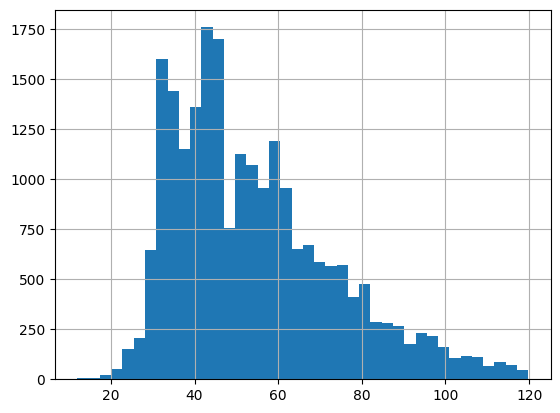

In [42]:
data['total_area'].hist(bins=40)

Основная массы квартир имеет площадь 30-60 кв.м. Квартиры с площадью менее 20 кв.м выглядят подозрительно, но возможно фактически это не квартира, а комната в общежитии. Оставим пока их без изменений

### Вывод предобработки данных

In [43]:
# сохраним количество строк и столбцов обновленной таблицы в переменной shape_2
shape_2 = data.shape
# выведем значение переменной на экран
print(shape_2)

(22300, 23)


In [44]:
# посчитаем сколько процентов данных от изначальных осталось для исследования
(shape_2[0]/shape[0]*100)

94.09679733322082

В ходе предобработки таблицы:
- переименовали столбец cityCenters_nearest;
- заполнили пропуски в таблице
- изменили типы данных, в соответствии с данными которые находятся в столбцах
- устранили неявные дубликаты в названиях населенных пунктов
- устранили анамальные значения в столбцах с высотой потолков, общей площадью и стоимостью

В процессе обработки таблицы было удалено около 6% от изначального числа данных, значит можно провести актуальный анализ.


## Добавление новых столбцов

Добавим столбец с ценой одного квадратного метра

In [45]:
data['price_square_meter'] = (data['last_price']/data['total_area']).round(2)

Добавим столбец с номером дня публикации объявления

In [46]:
data['day_publication'] = pd.DatetimeIndex(data['first_day_exposition']).weekday

Добавим столбец с номером месяца публикации объявления

In [47]:
data['month_publication'] = pd.DatetimeIndex(data['first_day_exposition']).month

Добавим столбец с годом публикации объявления

In [48]:
data['year_publication'] = pd.DatetimeIndex(data['first_day_exposition']).year

Добавим столбец с типом этажа квартиры

In [49]:
# создадим функцию type_floor()
def type_floor(row):
    if row['floor'] == 1:
        return 'первый'
    if row['floor'] == row['floors_total']:
        return 'последний'
    else:
        return 'другой'

In [50]:
# применим функцию методом apply()
data['type_apartment_floor'] = data.apply(type_floor, axis=1)

Добавим столбец с растоянием до центра города в километрах

In [51]:
data['distance_city_center_km'] = (data['city_centers_nearest']/1000).round(0)

Проверим данные в первых строках добавленных столбцов.

In [52]:
data.loc[:10, 'price_square_meter':'distance_city_center_km']

,price_square_meter,day_publication,month_publication,year_publication,type_apartment_floor,distance_city_center_km
0,120370.37,3,3,2019,другой,16.0
1,82920.79,1,12,2018,первый,19.0
2,92785.71,3,8,2015,другой,14.0
4,100000.00,1,6,2018,другой,8.0
5,95065.79,0,9,2018,другой,NaN
6,99195.71,3,11,2017,другой,19.0
7,110544.69,3,4,2019,другой,12.0
8,87454.76,2,5,2018,другой,NaN
9,88524.59,6,2,2017,другой,15.0
10,127525.25,3,11,2017,другой,14.0


### Вывод добавления новых столбцов

В таблицу были добавлены новые столбцы со следующими параметрами:
- цена одного квадратного метра;
- день недели публикации объявления;
- месяц публикации объявления;
- год публикации объявления;
- тип этажа квартиры («первый», «последний», «другой»);
- расстояние до центра города в километрах.

## Исследовательский анализ данных

### Изучение и описание параметров квартир

Изучение общей площади квартир.

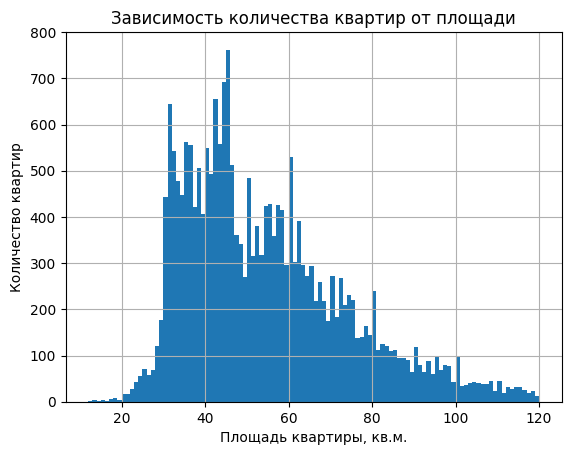

In [53]:
# построим гистограмму площади квартир, где минимальное значение 12 кв.м, а максимальное - 120 кв.м
data['total_area'].hist(bins=108, range=(12, 120))
plt.title('Зависимость количества квартир от площади')
plt.xlabel('Площадь квартиры, кв.м.')
plt.ylabel('Количество квартир')
plt.show()

(12.0, 120.0)

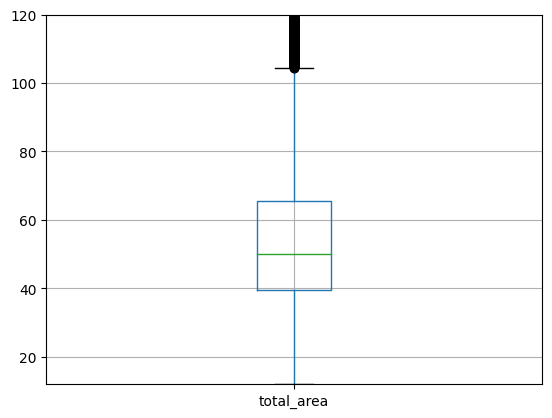

In [54]:
# построим диаграмму размаха для тех же данных
data.boxplot('total_area')
plt.ylim(12, 120)

Большее количество квартир в продаже имеет площадь от 30 до 75 кв.м., квартир до 20 кв.м. минимальное количество, максимум квартир площадью 45-46 кв.м., на диаграмме размаха медиана находится на уровне 50 кв.м., верхний "ус" начинается от 105 кв.м., все что выше этого значения можно считать выбросами. 

Изучение жилой площади квартир.

In [55]:
# посмотрим на числовое описание столбца с жилой площадью
data['living_area'].describe()

count    20573.000000
mean        31.128285
std         13.636481
min          2.000000
25%         18.300000
50%         29.700000
75%         40.000000
max        101.000000
Name: living_area, dtype: float64

(2.0, 101.0)

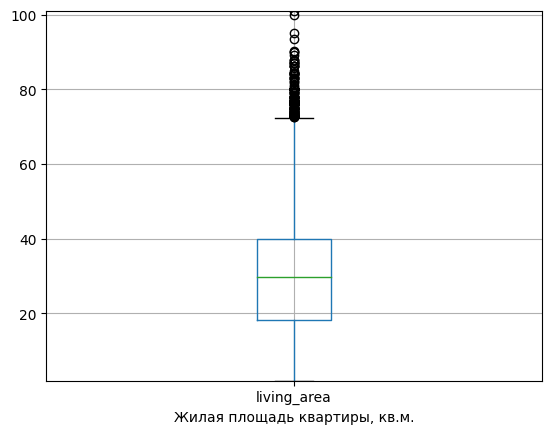

In [56]:
# построим диаграмму размаха с минимальным значением 2 кв.м., а максимальным - 101 кв.м.
data.boxplot('living_area')
plt.xlabel('Жилая площадь квартиры, кв.м.')
plt.ylim(2, 101)

Медиана на графике около 30 кв.м. Верхний "ус" упирается в значение около 70 кв.м., значит всё что выше - выбросы. При постоении гистограммы установим максимум - 70 кв.м. 

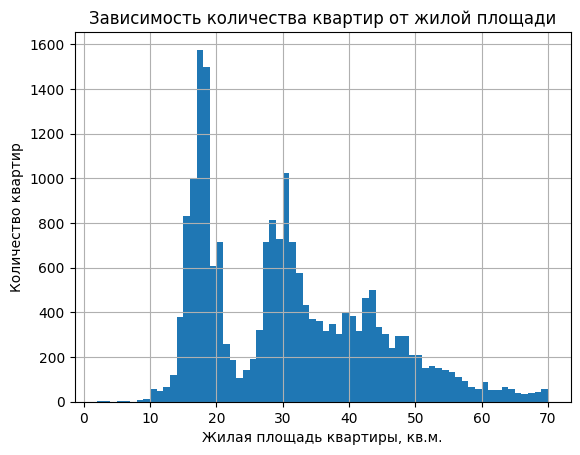

In [57]:
# построим гистограмму жилой площади квартир, где минимальное значение 2 кв.м, а максимальное - 70 кв.м
data['living_area'].hist(bins=68, range=(2, 70))
plt.title('Зависимость количества квартир от жилой площади')
plt.xlabel('Жилая площадь квартиры, кв.м.')
plt.ylabel('Количество квартир')
plt.show()

Наибольшее количество квартир с жилой площадью 16-21 и 28-33 кв.м., наблюдается спад 22-27 кв.м.

Изучим площадь кухни

In [58]:
# посмотрим на числовое описание столбца с площадью кухни
data['kitchen_area'].describe()

count    20197.000000
mean         9.879075
std          4.308865
min          1.300000
25%          7.000000
50%          9.000000
75%         11.200000
max         64.000000
Name: kitchen_area, dtype: float64

(1.0, 64.0)

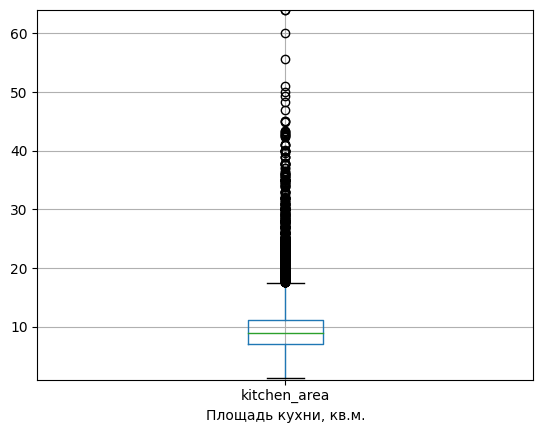

In [59]:
# построим диаграмму размаха с минимальным значением 1 кв.м., а максимальным - 64 кв.м.
data.boxplot('kitchen_area')
plt.xlabel('Площадь кухни, кв.м.')
plt.ylim(1, 64)

Медиана на графике около 9 кв.м. Верхний "ус" упирается в значение около 18 кв.м., значит всё что выше - выбросы. При постоении гистограммы установим максимум - 18 кв.м.

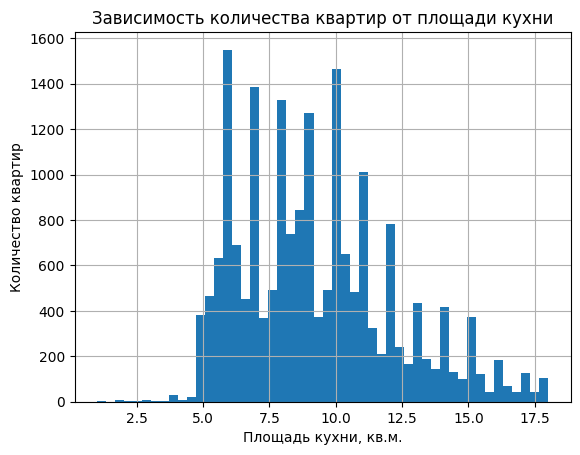

In [60]:
# построим гистограмму площади кухни, где минимальное значение 1 кв.м, а максимальное - 18 кв.м
data['kitchen_area'].hist(bins=50, range=(1, 18))
plt.title('Зависимость количества квартир от площади кухни')
plt.xlabel('Площадь кухни, кв.м.')
plt.ylabel('Количество квартир')
plt.show()

Наибольшее количество квартир с площадью кухни от 5 до 11 кв.м., заметны явные "пики" на целых числах

Рассмотрим цену квартир на момент снятия с публикации. Для удобства будем смотреть цену в млн.руб.

In [61]:
# посмотрим на числовое описание стоимости квартиры
data['last_price_mln'].describe()

count    22300.000000
mean         5.196352
std          2.875050
min          0.430000
25%          3.350000
50%          4.500000
75%          6.299000
max         19.999000
Name: last_price_mln, dtype: float64

(0.0, 20.0)

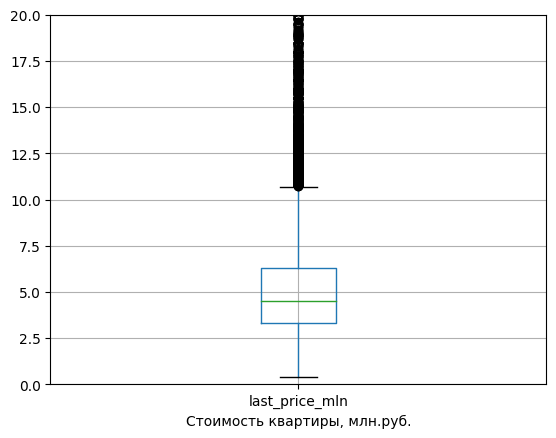

In [62]:
# построим диаграмму размаха для стоимости в млн.руб.
data.boxplot('last_price_mln')
plt.xlabel('Стоимость квартиры, млн.руб.')
plt.ylim(0, 20)

Медиана на графике около 4,5 млн.руб. Верхний "ус" упирается в значение около 11 млн.руб., значит всё что выше - выбросы. При постоении гистограммы установим максимум - 11 млн.руб.

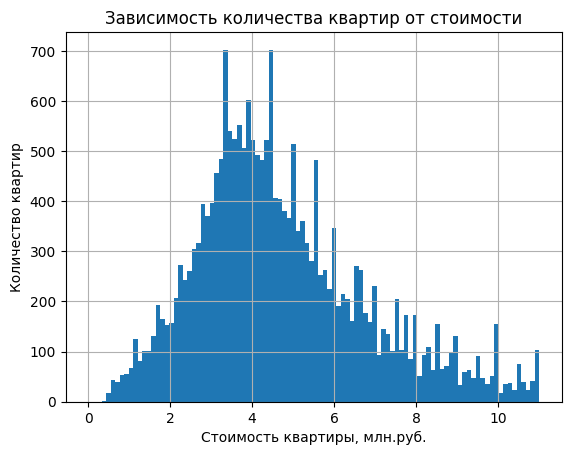

In [63]:
# построим гистограмму стоимости вкартиры, где минимальное значение 0, а максимальное - 11
data['last_price_mln'].hist(bins=100, range=(0, 11))
plt.title('Зависимость количества квартир от стоимости')
plt.xlabel('Стоимость квартиры, млн.руб.')
plt.ylabel('Количество квартир')
plt.show()

На рынке наибольшее количество квартир стоимостью 3,5-4,5 млн.руб., наблюдается заметный спад количества предложений стоимостью выше 5,5 млн.руб.

Посмотрим как распределяются квартиры на рынке по количеству комнат

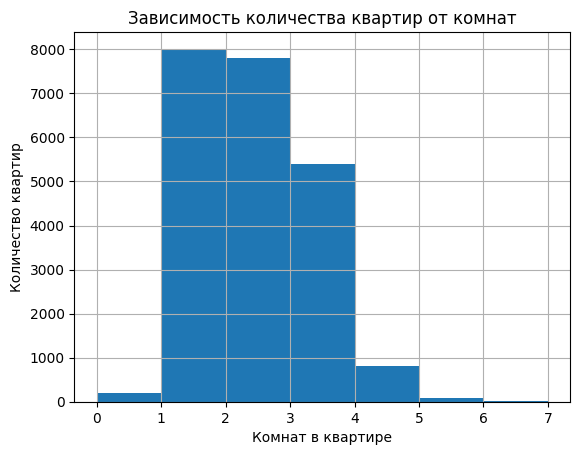

In [64]:
# построим гистограмму по количеству комнат в квартире
data['rooms'].hist(bins=7, range=(0, 7))
plt.title('Зависимость количества квартир от комнат')
plt.xlabel('Комнат в квартире')
plt.ylabel('Количество квартир')
plt.show()

Наибольшее количество предложений о продаже однокомнатных квартир, почти от них не отстают двухкомнатные. Квартир с четырьмя и более комнатами минимальное количество.

Исследование данных о высоте потолков

In [65]:
# посмотрим на числовое описание высоты потолков в продаваемых квартирах
data['ceiling_height'].describe()

count    22300.000000
mean         2.681526
std          0.230158
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max         14.000000
Name: ceiling_height, dtype: float64

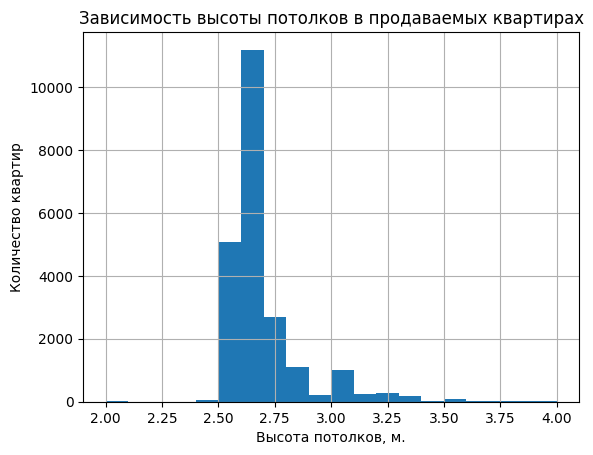

In [66]:
# построим гистограмму по высоте потолков
data['ceiling_height'].hist(bins=20, range=(2, 4))
plt.title('Зависимость высоты потолков в продаваемых квартирах')
plt.xlabel('Высота потолков, м.')
plt.ylabel('Количество квартир')
plt.show()

Большинство квартир имеет высоту потолков от 2,5 до 2,8 метров

Изучим распределение продаваемых квартир по этажам

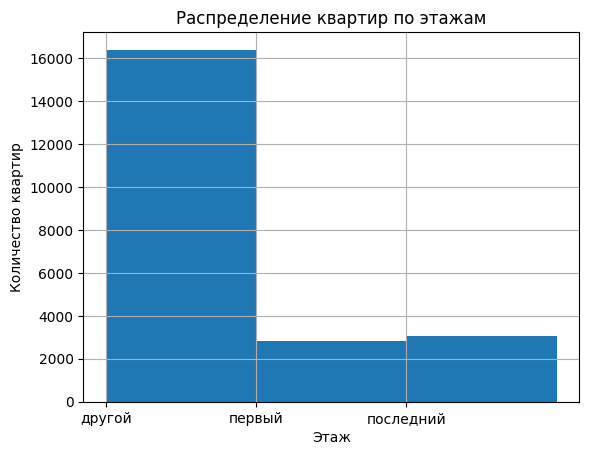

In [67]:
# построим гистограмму распределения квартир по этажам
data['type_apartment_floor'].hist(bins=3, range=(0, 3))
plt.title('Распределение квартир по этажам')
plt.xlabel('Этаж')
plt.ylabel('Количество квартир')
plt.show()

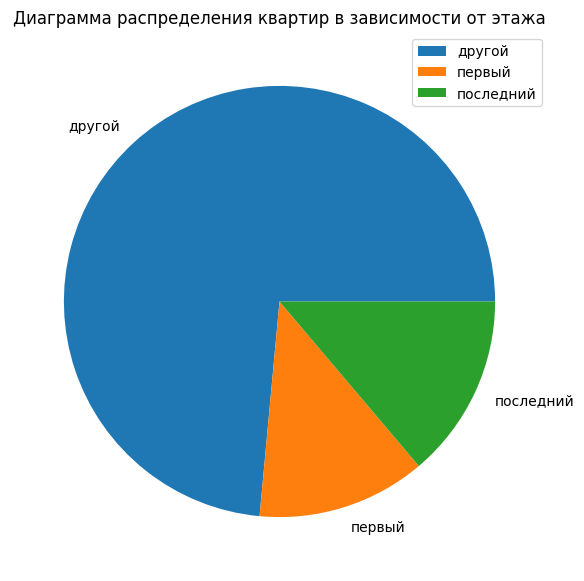

In [68]:
# построим диаграмму распределения квартир по этажам
data.pivot_table(index='type_apartment_floor',values='last_price',aggfunc='count').plot.pie(y='last_price', figsize=(7,7), label='', title='Диаграмма распределения квартир в зависимости от этажа')
plt.show()

Согласно круговой диаграммы количество продаваемых квартир на первом и последнем этажах составляет примерно по 25% от общего числа квартир.

Рассмотрим распределение продаваемых квартир среди домов разной этажности.

In [69]:
# посмотрим на числовое описание распределения квартир среди домов разной этажности
data['floors_total'].describe()

count    22300.000000
mean        10.801704
std          6.642354
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

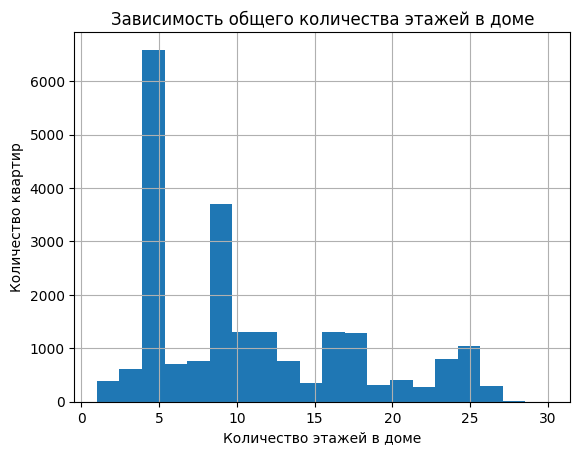

In [70]:
# построим гистограмму по общему количеству этажей в доме
data['floors_total'].hist(bins=20, range=(1, 30))
plt.title('Зависимость общего количества этажей в доме')
plt.xlabel('Количество этажей в доме')
plt.ylabel('Количество квартир')
plt.show()

Наибольшее количество предложений среди продаваемых квартир находится в пятиэтажных и девятиэтажных домах.

Рассмотрим расстояние до центра города в метрах

In [71]:
# посмотрим на числовое описание расстояния до центра города
data['city_centers_nearest'].describe()

count    16839.000000
mean     14666.028446
std       8508.474163
min        208.000000
25%      10199.500000
50%      13370.000000
75%      16518.000000
max      65968.000000
Name: city_centers_nearest, dtype: float64

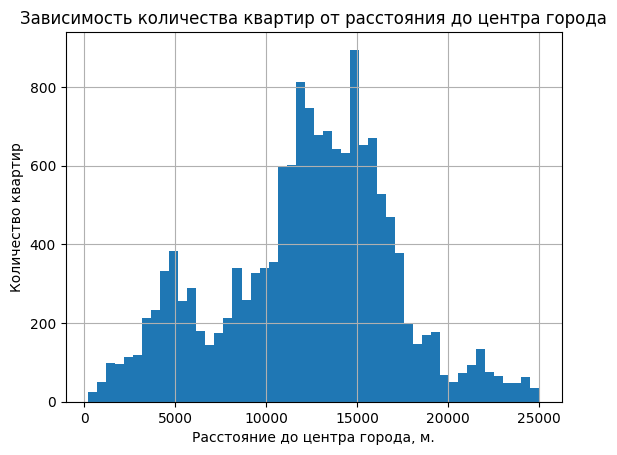

In [72]:
# построим гистограмму расстояния до центра города
data['city_centers_nearest'].hist(bins=50, range=(208, 25000))
plt.title('Зависимость количества квартир от расстояния до центра города')
plt.xlabel('Расстояние до центра города, м.')
plt.ylabel('Количество квартир')
plt.show()

Большинство продаваемых квартир находятся на расстоянии 11000 - 17000 метров, так же наблюдается всплеск в районе 4000-5000 метров.

Изучим расстояние до аэропорта

In [73]:
data['airports_nearest'].describe()

count    16822.000000
mean     28869.315718
std      12857.302849
min          0.000000
25%      18233.000000
50%      27016.000000
75%      37434.000000
max      84869.000000
Name: airports_nearest, dtype: float64

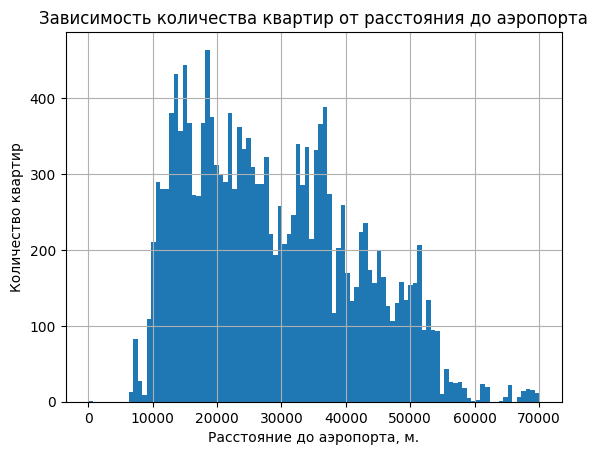

In [74]:
data['airports_nearest'].hist(bins=100, range=(0, 70000))
plt.title('Зависимость количества квартир от расстояния до аэропорта')
plt.xlabel('Расстояние до аэропорта, м.')
plt.ylabel('Количество квартир')
plt.show()

Явной зависимости не наблюдается, почти все квартиры находятся от аэропорта более чем на 10000 м.

Изучим расстояние до парка

In [75]:
data['parks_nearest'].describe()

count    7192.000000
mean      495.214266
std       342.019758
min         1.000000
25%       290.750000
50%       458.000000
75%       616.000000
max      3190.000000
Name: parks_nearest, dtype: float64

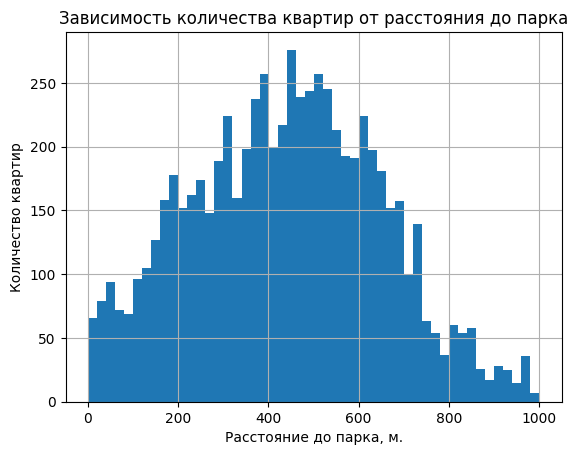

In [76]:
data['parks_nearest'].hist(bins=50, range=(1, 1000))
plt.title('Зависимость количества квартир от расстояния до парка')
plt.xlabel('Расстояние до парка, м.')
plt.ylabel('Количество квартир')
plt.show()

Явной зависимости количества квартир не наблюдается, парк в среднем находится на расстоянии 150-700 метров от квартиры.

Рассмотрим в какой день недели чаще выкладывают объявление о продаже квартиры

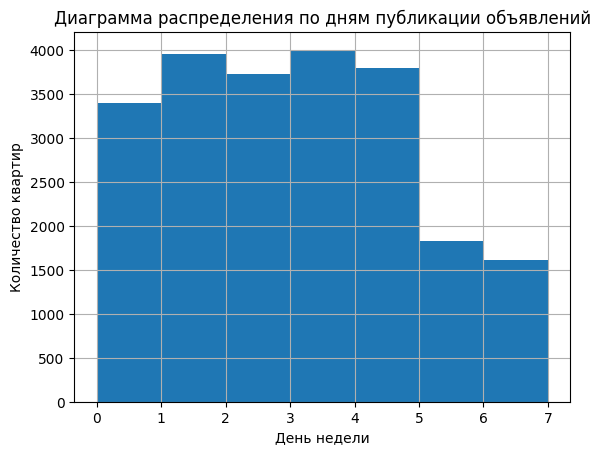

In [77]:
# построим гистограмму распределения квартир по дням публикации объявления
data['day_publication'].hist(bins=7, range=(0, 7))
plt.title('Диаграмма распределения по дням публикации объявлений')
plt.xlabel('День недели')
plt.ylabel('Количество квартир')
plt.show()

Меньше всего объявлений опубликовано в выходные дни - суббота, воскресенье; в остальные дни было выставлено на продажу примерно одинаковое количество квартир

Рассмотрим в какой месяц пользователи чаще выкладывают объявление о продаже квартиры

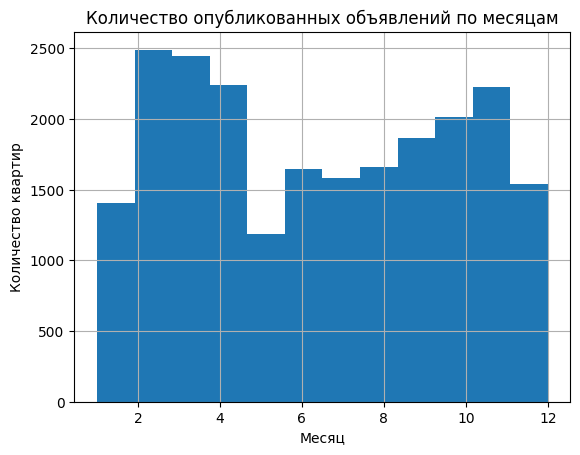

In [78]:
data['month_publication'].hist(bins=12, range=(1, 12))
plt.title('Количество опубликованных объявлений по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество квартир')
plt.show()

Больше всего объявлений опубликовано в феврале, марте, апреле и ноябре. Не так часто выставляют квартиры на продажу в январе и мае.

#### Вывод по параметрам квартир

1. Большее количество квартир в продаже имеет площадь от 30 до 75 кв.м., квартир до 20 кв.м. минимальное количество, максимум квартир площадью 45-46 кв.м.
2. Наибольшее количество квартир с жилой площадью 16-21 и 28-33 кв.м., наблюдается спад в районе 22-27 кв.м.
3. Наибольшее количество квартир с площадью кухни от 5 до 11 кв.м., заметны явные "пики" на целых числах.
4. На рынке наибольшее количество квартир стоимостью 3,5-4,5 млн.руб., наблюдается заметный спад количества предложений стоимостью выше 5,5 млн.руб.
5. Наибольшее количество предложений о продаже однокомнатных квартир, следом за ними идут двухкомнатные. Квартир с четырьмя и более комнатами минимальное количество.
6. Большинство квартир имеет высоту потолков от 2,5 до 2,8 метров.
7. Количество продаваемых квартир на первом и последнем этажах составляет примерно по 25% от общего числа квартир.
8. Наибольшее количество предложений среди продаваемых квартир находится в пятиэтажных и девятиэтажных домах.
9. Большинство продаваемых квартир находятся от центра города на расстоянии 11000 - 17000 метров, так же наблюдается всплеск в районе 4000-5000 метров.
10. Почти все квартиры находятся от аэропорта более чем на 10000 м., явной зависимости не выявлено.
11. Парк в среднем находится на расстоянии 150-700 метров от квартиры.
12. Меньше всего объявлений опубликовано в выходные дни - суббота, воскресенье; в остальные дни было выставлено на продажу примерно одинаковое количество квартир.
13. Больше всего объявлений опубликовано в феврале, марте, апреле и ноябре. Не так часто выставляют квартиры на продажу в январе и мае.

### Изучение скорости продажи квартиры

Изучим скорость продажи квартир

In [79]:
data['days_exposition'].describe()

count    19464.000000
mean       174.920469
std        213.088595
min          1.000000
25%         44.000000
50%         92.000000
75%        222.000000
max       1580.000000
Name: days_exposition, dtype: float64

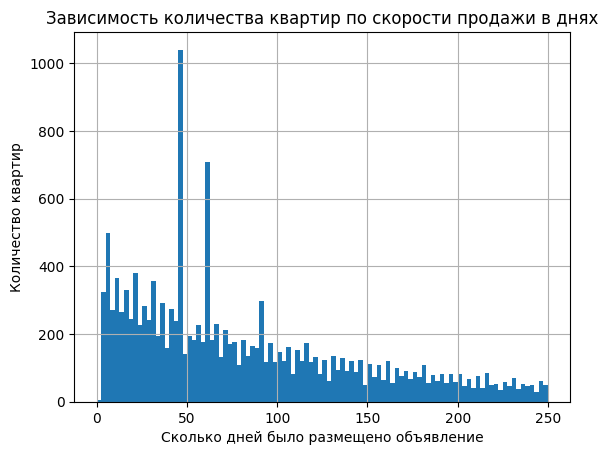

In [80]:
# построим гистограмму распределения квартир по скорости продажи в днях
data['days_exposition'].hist(bins=100, range=(0, 250))
plt.title('Зависимость количества квартир по скорости продажи в днях')
plt.xlabel('Сколько дней было размещено объявление')
plt.ylabel('Количество квартир')
plt.show()

Среднее значение размещения объявлений 175 дней, медиана равна 92. Среднее время продажи более характеризует медианное значение, так как оно менее подвержено выбросам. Согласно гистограмме квартиры продаются в течении двух-трех месяцев. Быстрыми продажами можно считать продажу в течении 44 дней (1й квартиль), необычно долгие продажи - более 223 дней (3й квартиль). 

### Изучение факторов, которые больше всего влияют на общую стоимость объекта

#### Зависимость цены от общей площади

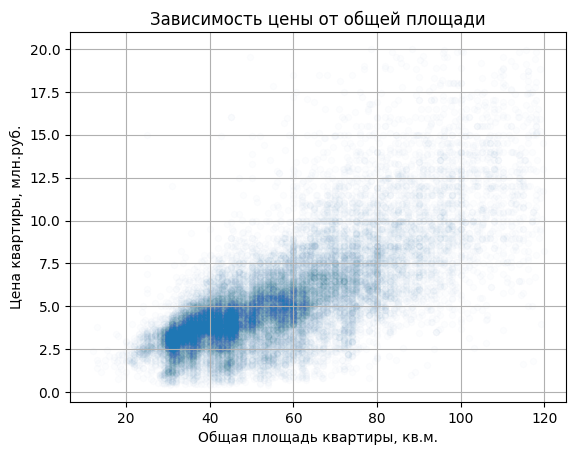

In [81]:
# построим диаграмму рассеяния 
data.plot(x='total_area', y='last_price_mln', kind='scatter', grid=True, alpha=0.01)
plt.title('Зависимость цены от общей площади')
plt.xlabel('Общая площадь квартиры, кв.м.')
plt.ylabel('Цена квартиры, млн.руб.')
plt.show()

In [82]:
# поссчитаем коэффициент корреляции Пирсона
data['last_price'].corr(data['total_area'])

0.7343418638398196

Согласно коэффициенту корреляции между ценой и общей плошадью квартиры есть высокая взаимосвязь - чем больше площадь, тем выше будет цена. Основное количество квартир имеет площадь 30-45 кв.м. ценой 2,5-5 млн.руб.

#### Зависимость цены от жилой площади

<function matplotlib.pyplot.show(close=None, block=None)>

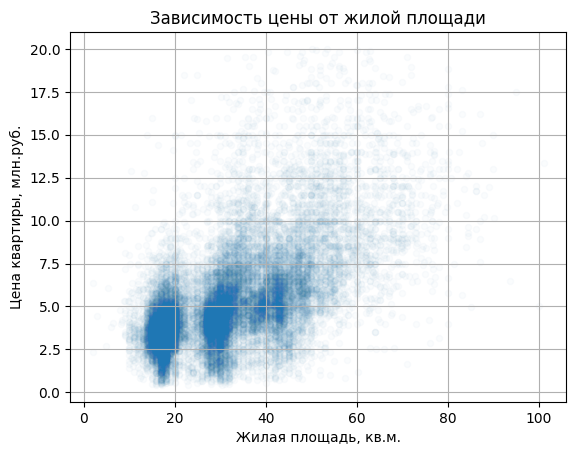

In [83]:
data.plot(x='living_area', y='last_price_mln', kind='scatter', grid=True, alpha=0.02)
plt.title('Зависимость цены от жилой площади')
plt.xlabel('Жилая площадь, кв.м.')
plt.ylabel('Цена квартиры, млн.руб.')
plt.show

In [84]:
# поссчитаем коэффициент корреляции Пирсона
data['last_price'].corr(data['living_area'])

0.5972247315300264

Коэффициент корреляции между ценой и жилой плошадью равен 0,59, это не достаточно высоко чтобы говорить о прямой взаимосвязи, жилая площадь если и влияет на цену, то не достаточно сильно. Основное количество квартир имеет жилую площадь 15-20 и 35-30 кв.м., цены таких квартир 2-5 млн.руб.

#### Зависимость цены от площади кухни

<function matplotlib.pyplot.show(close=None, block=None)>

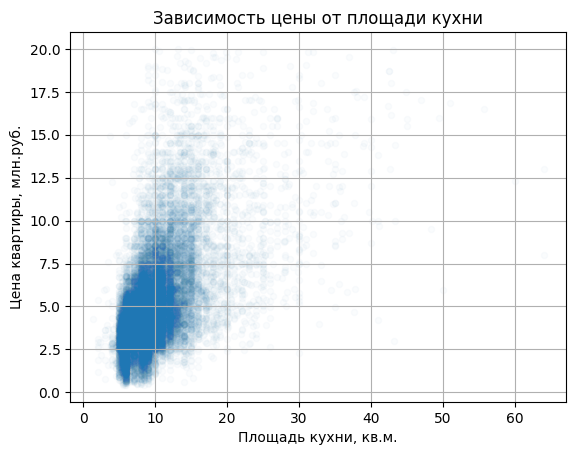

In [85]:
data.plot(x='kitchen_area', y='last_price_mln', kind='scatter', grid=True, alpha=0.02)
plt.title('Зависимость цены от площади кухни')
plt.xlabel('Площадь кухни, кв.м.')
plt.ylabel('Цена квартиры, млн.руб.')
plt.show

In [86]:
# поссчитаем коэффициент корреляции Пирсона
data['last_price'].corr(data['kitchen_area'])

0.5427577634639105

Коэффициент корреляции между ценой и плошадью кухни не достаточно высок чтобы говорить о прямой взаимосвязи, если зависимость цены от площади кухни и есть, то она не настолько прямая. Основное количество квартир имеет площадь кухни 5-13 кв.м., цены таких квартир 1-7 млн.руб.

#### Зависимость цены от количества комнат

In [87]:
# поссчитаем коэффициент корреляции Пирсона
data['last_price'].corr(data['rooms'])

0.43912476830389807

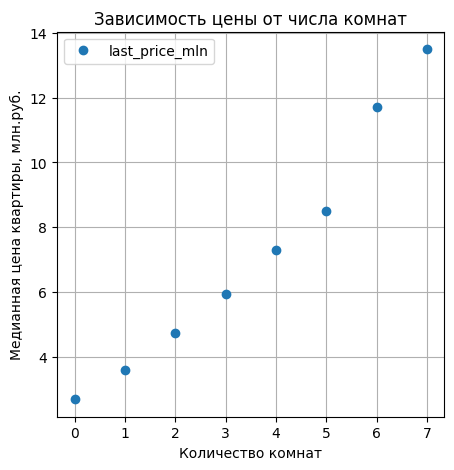

In [88]:
# построим график зависимости цены от количества комнат
data.pivot_table(index='rooms', values='last_price_mln', aggfunc='median').plot(style='o', grid=True, figsize=(5, 5))
plt.title('Зависимость цены от числа комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Медианная цена квартиры, млн.руб.')
plt.show()

Коэффициент корреляции между ценой и количеством комнат равен 0,44, это не достаточно высоко чтобы говорить о прямой взаимосвязи. На графике рост цены с увеличением количества комнат скорее связан с тем, что общая площадь так же растет.

#### Зависимость цены от этажа на котором расположена квартира (первый, последний, другой)

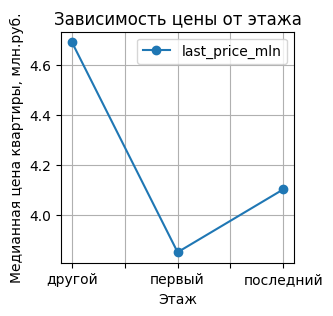

In [89]:
# построим график зависимости цены от этажа на котором расположена квартира (первый, последний, другой)
data.pivot_table(index='type_apartment_floor', values='last_price_mln', aggfunc='median').plot(style='o-', grid=True, figsize=(3, 3))
plt.title('Зависимость цены от этажа')
plt.xlabel('Этаж')
plt.ylabel('Медианная цена квартиры, млн.руб.')
plt.show()

Из графика следует, что цена квартир на первом этаже ниже чем на последнем. Квартиры, расположенные на остальных этажах стоят значительно дороже.

#### Зависимость цены от дня размещения объявления

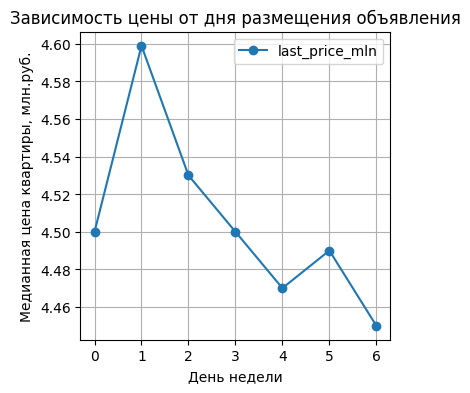

In [90]:
data.pivot_table(index='day_publication', values='last_price_mln', aggfunc='median').plot(style='o-', grid=True, figsize=(4, 4))
plt.title('Зависимость цены от дня размещения объявления')
plt.xlabel('День недели')
plt.ylabel('Медианная цена квартиры, млн.руб.')
plt.show()

Отсутствует зависимость цены квартиры от дня недели в который было опубликовано объявление.

#### Зависимость цены от месяца размещения объявления

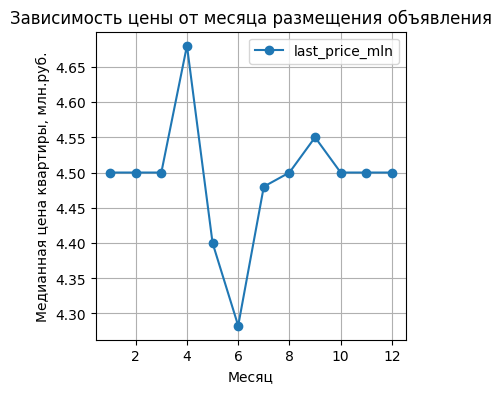

In [91]:
data.pivot_table(index='month_publication', values='last_price_mln', aggfunc='median').plot(style='o-', grid=True, figsize=(4, 4))
plt.title('Зависимость цены от месяца размещения объявления')
plt.xlabel('Месяц')
plt.ylabel('Медианная цена квартиры, млн.руб.')
plt.show()

Отсутствует зависимость цены квартиры от месяца в который было опубликовано объявление.

#### Зависимость цены от года размещения объявления

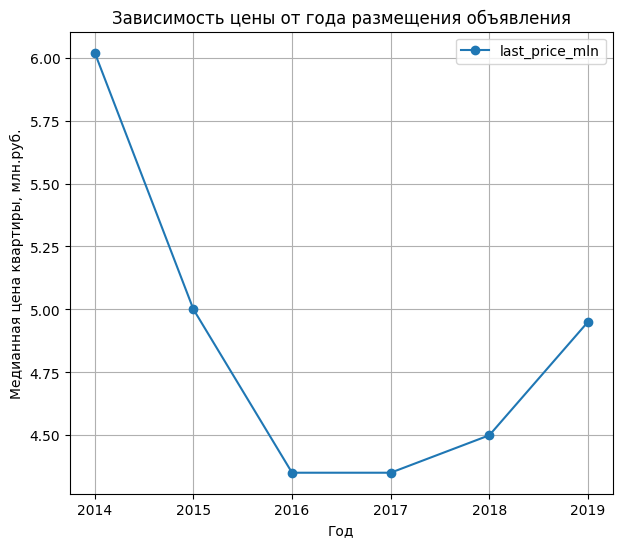

In [92]:
data.pivot_table(index='year_publication', values='last_price_mln', aggfunc='median').plot(style='o-', grid=True, figsize=(7, 6))
plt.title('Зависимость цены от года размещения объявления')
plt.xlabel('Год')
plt.ylabel('Медианная цена квартиры, млн.руб.')
plt.show()

По графику на первый взгляд кажется, что стоимость квартир падала до 2017 года, а потом снова стала расти. Проверим как распределяется стоимость квартир с разным количеством комнат по годам публикации объявления.

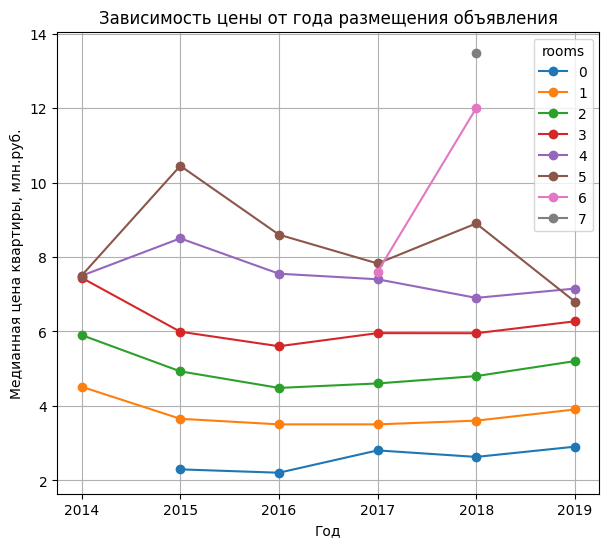

In [93]:
data.pivot_table(index='year_publication', columns='rooms', values='last_price_mln', aggfunc='median').plot(style='o-', grid=True, figsize=(7, 6))
plt.title('Зависимость цены от года размещения объявления')
plt.xlabel('Год')
plt.ylabel('Медианная цена квартиры, млн.руб.')
plt.show()

По этому графику более наглядно видно что зависимости цены квартир от года размещения объявления нет.

Зато график изменения площади продаваемых квартир по годам почти полностью совпадает с графиком зависимости стоимости от года размещения объявления. Значит изменение цены связано с уменьшением площади квартир.

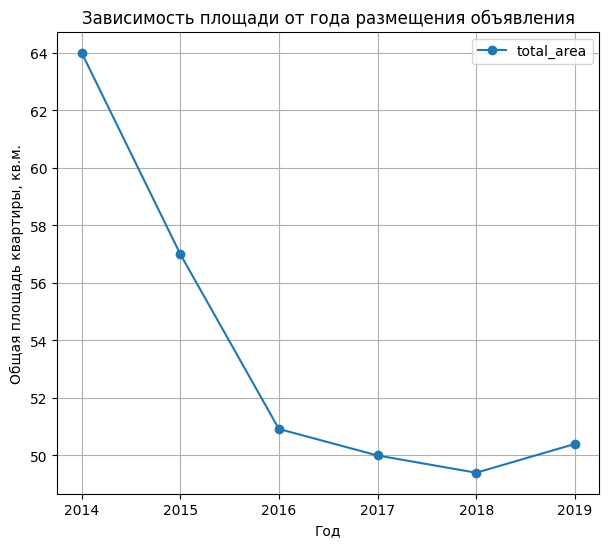

In [94]:
data.pivot_table(index='year_publication', values='total_area', aggfunc='median').plot(style='o-', grid=True, figsize=(7, 6))
plt.title('Зависимость площади от года размещения объявления')
plt.xlabel('Год')
plt.ylabel('Общая площадь квартиры, кв.м.')
plt.show()

#### Вывод по зависимости цены от различных параметров

Цена квартиры наиболее всего зависит от общей площади квартиры и этажа на котором квартира расположена. Чем больше площадь квартиры, тем больше стоимость; квартиры на первом и последнем этажах значительно дешевле. 
Чем больше комнат в квартире и жилая площадь в ней, тем стоимость будет выше. Но в то же время очевидно что с ростом количества комнат жилая и общая площадь тоже растет. График изменения площади продаваемых квартир по годам почти полностью совпадает с графиком зависимости стоимости от года размещения объявления. Значит изменение цены связано с уменьшением площади квартир.
Явных зависимостей цены от даты размещения объявления не обнаружено.

### Рассчет средней цены одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений

In [95]:
# сформируем сводную таблицу со средней ценой квадратного метра по городам
data_price_square_meter = data.pivot_table(index='locality_name', values='price_square_meter').round(2)
# добавим в таблицу столбец с количеством объявлений в городах
data_price_square_meter['count'] = data.pivot_table(index='locality_name', values='price_square_meter', aggfunc='count')

In [96]:
# выведем таблицу на экран, отсортировав по количеству объявлений
data_price_square_meter.sort_values('count', ascending=False).head(10)

,price_square_meter,count
locality_name,,
Санкт-Петербург,108900.81,14466
поселок Мурино,85629.57,552
поселок Шушары,78539.83,438
Всеволожск,67222.43,394
Пушкин,101881.54,349
Колпино,75370.03,336
поселок Парголово,90332.26,326
Гатчина,68919.47,304
деревня Кудрово,92473.55,299


Самая высокая стоимость квадратного метра в Санкт-Петербурге и Пушкино, низкая стоимость в Выборге, Всеволожске и Гатчине

### Рассчет средней цены каждого километра до центра города в Санкт-Петербурге

In [97]:
# создадим новую таблицу с данными только по Санкт-Петербургу
data_distance = data.query('locality_name == "Санкт-Петербург"')

In [98]:
# выведем на экран сводную таблицу со средней ценой одного кв.м. по каждому километру до центра города
data_distance.pivot_table(index='distance_city_center_km', values='price_square_meter', aggfunc='mean').head(10)

,price_square_meter
distance_city_center_km,
0.0,122387.692500
1.0,133403.655852
2.0,127912.246066
3.0,115856.002810
4.0,124325.445712
5.0,128329.399023
6.0,128751.404419
7.0,124578.966006
8.0,121571.877292


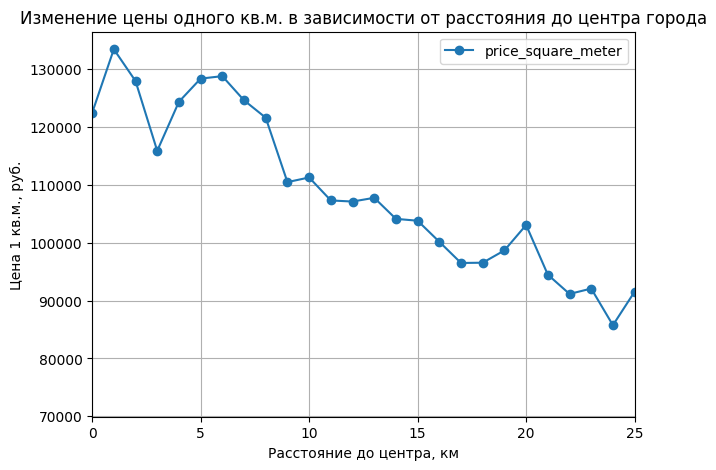

In [99]:
# построим график изменения цены одного кв.м. в зависимости от расстояния до центра города
data_distance.pivot_table(index='distance_city_center_km', values='price_square_meter', aggfunc='mean').plot(style='o-', grid=True, xlim=(0,25), figsize=(7, 5))
plt.title('Изменение цены одного кв.м. в зависимости от расстояния до центра города')
plt.xlabel('Расстояние до центра, км')
plt.ylabel('Цена 1 кв.м., руб.')
plt.show()

In [100]:
# поссчитаем коэффициент корреляции Пирсона
data_distance['price_square_meter'].corr(data_distance['distance_city_center_km'])

-0.3406116501582761

Из графика видно, что цена одного квадратного метра уменьшается вместе с удалением от центра.

### Вывод исследовательского анализа данных

В ходе изучения параметров квартир были изучены: общая площадь, жилая площадь, площадь кухни, цена на момент снятия с публикации, количество комнат в квартире, высота потолков, распределение квартир по этажам, распределение квартир среди домов разной этажности, расстояние до центра города, расстояние до аэропорта и парка, дата публикации объявления. Получены следующие результаты:
1. Большее количество квартир в продаже имеет площадь от 30 до 75 кв.м., квартир до 20 кв.м. минимальное количество, максимум квартир площадью 45-46 кв.м.
2. Наибольшее количество квартир с жилой площадью 16-21 и 28-33 кв.м., наблюдается спад в районе 22-27 кв.м.
3. Наибольшее количество квартир с площадью кухни от 5 до 11 кв.м., заметны явные "пики" на целых числах.
4. На рынке наибольшее количество квартир стоимостью 3,5-4,5 млн.руб., наблюдается заметный спад количества предложений стоимостью выше 5,5 млн.руб.
5. Наибольшее количество предложений о продаже однокомнатных квартир, следом за ними идут двухкомнатные. Квартир с четырьмя и более комнатами минимальное количество.
6. Большинство квартир имеет высоту потолков от 2,5 до 2,8 метров.
7. Количество продаваемых квартир на первом и последнем этажах составляет примерно по 25% от общего числа квартир.
8. Наибольшее количество предложений среди продаваемых квартир находится в пятиэтажных и девятиэтажных домах.
9. Большинство продаваемых квартир находятся от центра города на расстоянии 11000 - 17000 метров, так же наблюдается всплеск в районе 4000-5000 метров.
10. Почти все квартиры находятся от аэропорта более чем на 10000 м., явной зависимости не выявлено.
11. Парк в среднем находится на расстоянии 150-700 метров от квартиры.
12. Меньше всего объявлений опубликовано в выходные дни - суббота, воскресенье; в остальные дни было выставлено на продажу примерно одинаковое количество квартир.
13. Больше всего объявлений опубликовано в феврале, марте, апреле и ноябре. Не так часто выставляют квартиры на продажу в январе и мае.

Среднее время продажи квартир - 92 дня. Быстрой продажей можно считать продажу в течении 44 дней, необычно долгой - более 223 дня.

Цена квартиры наиболее всего зависит от общей площади квартиры и этажа на котором квартира расположена(первый, последний или другой). Чем больше площадь квартиры, тем больше стоимость; квартиры на первом и последнем этажах значительно дешевле. Чем больше комнат в квартире и жилая площадь в ней, тем стоимость будет выше. Но в то же время очевидно, что с ростом количества комнат жилая и общая площадь тоже растет. Явных зависимостей цены от даты размещения объявления не обнаружено.

Наибольшее число объявлений в Санкт-Петербурге - 14532, в нем же и самая высокая стоимость одного квадратного метра - 108 899,84. Так же высокая стоимость квадратного местра в Пушкино. Низкая стоимость в Выборге, Всеволожске и Гатчине - от 58229 до 68919.

В городе Санкт-Петербург стоимость одного квадратного метра уменьшается вместе с удалением от центра города.

## Общий вывод исследования рынка недвижимости

В ходе работы были изучены и обработаны данные сервиса Яндекс Недвижимость — архив объявлений за несколько лет о продаже квартир в Санкт-Петербурге и соседних населённых пунктах. 

На первом этапе изучена общая информация. В файле имеется 23699 записей, в некоторых столбцах есть пропуски и тип данных указан не верно. Явные дубликаты не обнаружены.

Во время предобработки данных:
- переименован столбец cityCenters_nearest в соответствии со "змеиным" регистром;
- устранены неявные дубликаты в названиях населенных пунктов;
- устранены аномальные значения в столбцах с высотой потолков, общей площадью и стоимостью;
- заполнены пропуски в столбцах: ceiling_height, is_apartment, balcony;
- изменен тип данных в столбцах: last_price, first_day_exposition.

В таблицу были добавлены новые столбцы со следующими параметрами:
- цена одного квадратного метра;
- день недели публикации объявления;
- месяц публикации объявления;
- год публикации объявления;
- тип этажа квартиры («первый», «последний», «другой»);
- расстояние до центра города в километрах.

В процессе обработки таблицы было удалено около 6% от изначального числа данных.

В ходе изучения параметров квартир были изучены: общая площадь, жилая площадь, площадь кухни, цена на момент снятия с публикации, количество комнат в квартире, высота потолков, распределение квартир по этажам, распределение квартир среди домов разной этажности, расстояние до центра города, расстояние до аэропорта и парка, дата публикации объявления. Получены следующие результаты:
1. Большее количество квартир в продаже имеет площадь от 30 до 75 кв.м., квартир до 20 кв.м. минимальное количество, максимум квартир площадью 45-46 кв.м.
2. Наибольшее количество квартир с жилой площадью 16-21 и 28-33 кв.м., наблюдается спад в районе 22-27 кв.м.
3. Наибольшее количество квартир с площадью кухни от 5 до 11 кв.м., заметны явные "пики" на целых числах.
4. На рынке наибольшее количество квартир стоимостью 3,5-4,5 млн.руб., наблюдается заметный спад количества предложений стоимостью выше 5,5 млн.руб.
5. Наибольшее количество предложений о продаже однокомнатных квартир, следом за ними идут двухкомнатные. Квартир с четырьмя и более комнатами минимальное количество.
6. Большинство квартир имеет высоту потолков от 2,5 до 2,8 метров.
7. Количество продаваемых квартир на первом и последнем этажах составляет примерно по 25% от общего числа квартир.
8. Наибольшее количество предложений среди продаваемых квартир находится в пятиэтажных и девятиэтажных домах.
9. Большинство продаваемых квартир находятся от центра города на расстоянии 11000 - 17000 метров, так же наблюдается всплеск в районе 4000-5000 метров.
10. Почти все квартиры находятся от аэропорта более чем на 10000 м., явной зависимости не выявлено.
11. Парк в среднем находится на расстоянии 150-700 метров от квартиры.
12. Меньше всего объявлений опубликовано в выходные дни - суббота, воскресенье; в остальные дни было выставлено на продажу примерно одинаковое количество квартир.
13. Больше всего объявлений опубликовано в феврале, марте, апреле и ноябре. Не так часто выставляют квартиры на продажу в январе и мае.

Среднее время продажи квартир - 92 дня. Быстрой продажей можно считать продажу в течении 44 дней, необычно долгой - более 223 дня.

Цена квартиры наиболее всего зависит от общей площади квартиры и этажа на котором квартира расположена(первый, последний или другой). Чем больше площадь квартиры, тем больше стоимость; квартиры на первом и последнем этажах значительно дешевле. Чем больше комнат в квартире и жилая площадь в ней, тем стоимость будет выше. Но в то же время очевидно, что с ростом количества комнат жилая и общая площадь тоже растет. График изменения площади продаваемых квартир по годам почти полностью совпадает с графиком зависимости стоимости от года размещения объявления. Значит изменение цены связано с уменьшением площади квартир. Явных зависимостей цены от даты размещения объявления не обнаружено.

Наибольшее число объявлений в Санкт-Петербурге - 14532, в нем же и самая высокая стоимость одного квадратного метра - 108 899,84. Так же высокая стоимость квадратного местра в Пушкино. Низкая стоимость в Выборге, Всеволожске и Гатчине - от 58229 до 68919.

В городе Санкт-Петербург стоимость одного квадратного метра уменьшается вместе с удалением от центра города.